# 展開点とエネルギー ― CLNの読み違いを防ぐ

[CLNとは何か](00_what_is_cln.ipynb)の続きです。ここでは、同じ丸線に対して展開点を変えると素子値と誤差がどう変わるかを実行して確認します。FEMやWolframは不要です。

## 1. 展開点は物理系の変更ではない

厳密な丸線インピーダンス$Z(s)$は同じです。一方、$q=s-s_0$で展開して有限段で打ち切った回路は、$s_0$によって変わります。同じ対象でも素子値が変わるのは、この表現と近似の変更によるものです。

ここで$s_0$は**正の実数Laplace点**です。「周波数$f_0$で展開」という言葉から$s_0=j2\pi f_0$と読み替えてはいけません。以降は$z=\tau s$、$z_0=\tau s_0$、$q=z-z_0$という無次元表示です。

下のコードはBessel解のTaylor係数から互除法で7要素のType2を求めます。場からのエネルギー抽出とは独立の**解析基準**として使う計算であり、これ自体をFEMのCLN生成と呼びません。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
mp.mp.dps=80
plt.rcParams.update({"figure.dpi":110,"font.size":11})
def F(z):
    k=mp.sqrt(z)
    return k*mp.besseli(0,k)/(2*mp.besseli(1,k))
def reciprocal(c):
    out=[1/c[0]]
    for n in range(1,len(c)):
        out.append(-mp.fsum(c[i]*out[n-i] for i in range(1,n+1))/c[0])
    return out
def extract(z0,count=7):
    seq=mp.taylor(F,mp.mpf(z0),count+2)
    result=[]
    for n in range(count):
        result.append(seq[0] if n%2==0 else 1/seq[0])
        seq=seq[1:]
        if n<count-1: seq=reciprocal(seq)
    assert all(v>0 for v in result)
    return result
models={z0:extract(z0) for z0 in (1,10,80)}
def ladder(c,q):
    if q==0:return c[0]
    value=c[-1]
    for i in range(len(c)-2,-1,-1):
        value=c[i]+value if i%2==0 else q*c[i]*value/(q*c[i]+value)
    return value
for z0,c in models.items():
    assert abs(ladder(c,mp.mpf(0))/F(z0)-1)<mp.mpf('1e-65')
    print('z0=',z0,'[R0,L1,R2,L3,R4,L5,R6]=',[float(x) for x in c])
    # A seven-element truncation should have order-seven contact.
    errors=[abs(ladder(c,mp.mpf(z0)*h)/F(mp.mpf(z0)*(1+h))-1) for h in (mp.mpf('.001'),mp.mpf('.0001'))]
    order=mp.log10(errors[0]/errors[1])
    assert abs(order-7)<mp.mpf('.03')
    print('measured local order:',float(order))


z0= 1 [R0,L1,R2,L3,R4,L5,R6]= [1.1200968619350449, 0.1154798818183099, 3.0666053062273364, 0.06196250572931506, 5.0213805346565925, 0.04156588522682069, 7.010558107106398]
measured local order: 6.999890627666975
z0= 10 [R0,L1,R2,L3,R4,L5,R6]= [1.9251628969197876, 0.07189107172431987, 3.856377388147359, 0.0558769334988995, 5.274075000305616, 0.040492918748154846, 7.120302521764528]
measured local order: 6.999377596363988
z0= 80 [R0,L1,R2,L3,R4,L5,R6]= [4.745877395632916, 0.027781564265668093, 9.016668512330396, 0.027636619085364203, 9.098611014023604, 0.02717689216716186, 9.38715972604435]
measured local order: 6.998710526156177


## 2. 実数軸の局所一致と、交流帯域の一致を分けて見る

左図は正の実数$z$上、右図は物理的な交流$s=j\omega$上の誤差です。実数展開点に近いところで誤差が小さいことと、使いたい交流帯域で十分に正確なことは別の確認です。右図の誤差を見ずに「展開点を入れたので高精度」とは言えません。


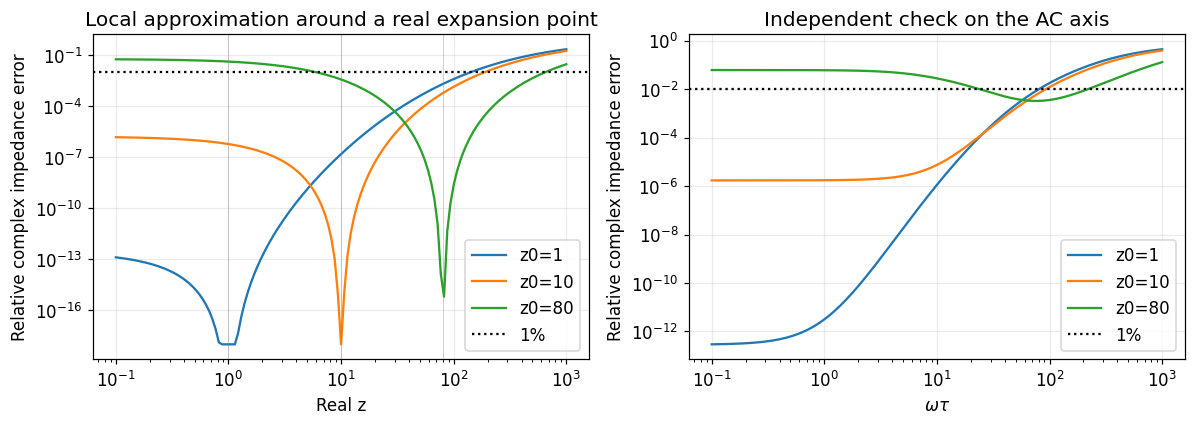

In [2]:
grid=np.logspace(-1,3,141)
fig,ax=plt.subplots(1,2,figsize=(11,4))
for z0,c in models.items():
    real_error=[float(abs(ladder(c,mp.mpf(v)-z0)/F(mp.mpf(v))-1)) for v in grid]
    ac_error=[float(abs(ladder(c,mp.mpc(0,v)-z0)/F(mp.mpc(0,v))-1)) for v in grid]
    assert np.isfinite(real_error).all() and np.isfinite(ac_error).all()
    ax[0].loglog(grid,np.maximum(real_error,1e-18),label=f'z0={z0}')
    ax[0].axvline(z0,color='gray',lw=.6,alpha=.4)
    ax[1].loglog(grid,np.maximum(ac_error,1e-18),label=f'z0={z0}')
for a in ax:
    a.axhline(.01,color='black',ls=':',label='1%');a.grid(alpha=.25);a.legend();a.set_ylabel('Relative complex impedance error')
ax[0].set(xlabel='Real z',title='Local approximation around a real expansion point')
ax[1].set(xlabel=r'$\omega\tau$',title='Independent check on the AC axis')
plt.tight_layout();plt.show()


## 3. 正のR・Lが並んでいても、展開点付き回路の解釈には注意

Type2のインダクタンス枝は$qL=(s-s_0)L$です。物理的な$s$で書き直すと$sL-s_0L$となり、通常のインダクタンスだけではありません。したがって、$q$表示の要素が正という理由だけで、$s$上の有限近似回路が受動的だと結論できません。極・安定性・対象帯域誤差は別途確認します。

Type1はさらに$Z/s$を展開し、$R/q$という枝を含みます。Type1とType2を「同じRとLの別名」と考えてはいけません。

| 比較するもの | 一致を期待できるもの |
|---|---|
| 同じZ、同じ展開点、同じType・規格化・打切り手順 | 非退化な場合の連分数係数 |
| A法とT法、同じType | 正しく対応づけた連続体の場と回路定数。有限メッシュでは誤差が残る |
| Type1とType2 | 近似対象のZ。素子値の同一性は要求しない |
| 展開点が異なる有限回路 | 指定帯域での近似精度を測って比較する |

## 4. どの積分がR・Lになるのか

このリポジトリの規格化では、Type2の偶数段は
$$R_{2n}^{-1}=P_j(E_{2n})+s_0W_m(H_{2n}),\quad
H_{2n+1}=R_{2n}H_{2n}+H_{2n-1},\quad L_{2n+1}=W_m(H_{2n+1}).$$
一方Type1は$R_{2n}^{-1}=P_j(E_{2n})$、奇数段は$L=(P_j+s_0W_m)/s_0$です。$W_m$はここでは$\int\mu H^2$という二次形式の名前で、蓄積エネルギーの$1/2$を含めていません。

「エネルギーベース」とは、**場の積分と規格化から各素子の意味を導ける**ということです。展開点付きのすべてのRを、そのまま純粋なジュール損失と呼ぶことではありません。

## 5. 今回わかったことと、まだ示していないこと

A法とT法の既存の境界条件・規格化を変更したのではありません。未知量からの物理場の復元を追い、同じ回路に至ることを示しました。

- **Type2**：丸線、正の実数展開点、R0/L1/R2/L3の解析導出。独立レビュー済み。
- **Type1**：丸線、正の実数展開点、L-1/R0/L1/R2の解析導出。A/T別の有限要素解が同じ解析値へ収束。
- **未証明**：任意段数、一般3D混合定式化、複素展開点、非線形場へのこの証明の拡張。

以下は保存済みのNGSolve再現結果です。新しくsolveした値ではありません。実行し直すには[Type1ノート](type1_same_circuit.ipynb)を使ってください。


A max relative element error, finest mesh: 2.0957589931258624e-06
T max relative element error, finest mesh: 1.104252388195448e-06


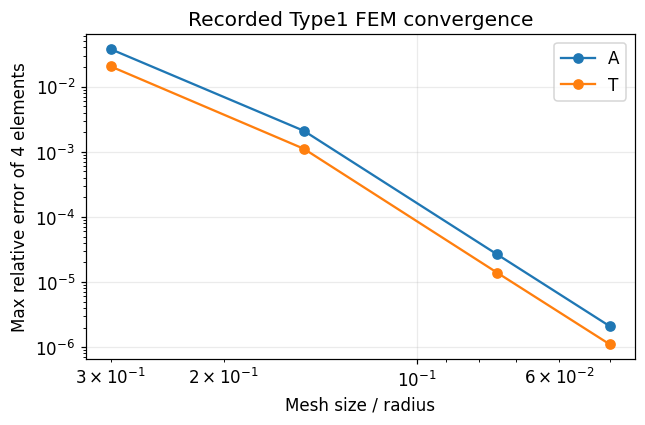

A/T difference, finest mesh: 3.2000078477034677e-06


In [3]:
import json
from pathlib import Path
base=Path.cwd() if Path.cwd().name=='docs' else Path.cwd()/'docs'
record=json.loads((base/'data/type1_radia_ngsolve.json').read_text())
assert record['passed']
h=np.array([row['maxh'] for row in record['cases']])
fig,ax=plt.subplots(figsize=(6,4))
for name in ('A','T'):
    err=[max(abs(v) for v in row[name]['relative_errors']) for row in record['cases']]
    ax.loglog(h,err,'o-',label=name)
    print(name,'max relative element error, finest mesh:',err[-1])
ax.set(xlabel='Mesh size / radius',ylabel='Max relative error of 4 elements',title='Recorded Type1 FEM convergence')
ax.invert_xaxis();ax.grid(alpha=.25);ax.legend();plt.tight_layout();plt.show()
print('A/T difference, finest mesh:',record['fine_A_T_relative_difference'])


## 導出を追う

[Type2の記号検証](type2_same_circuit.ipynb) → [Type1の記号検証とFEM再現](type1_same_circuit.ipynb)。

本ノートのグラフは公開コードとBessel解析解から生成しています。7要素のグラフは**解析的な連分数抽出の実演**です。A/Tの場から同じ回路になる証明を7要素まで拡張した、という意味ではありません。
